# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Rafi Baihaqi
- Email: rafibaihaqi0@gmail.com
- Username Dicoding: rafi_baihaqi_YQdp

## Persiapan

### Business Understanding

Jaya Jaya Institut merupakan institusi pendidikan yang telah menghasilkan banyak lulusan dengan reputasi yang sangat baik sejak didirikan. Meskipun demikian, institusi ini menghadapi permasalahan berupa tingginya jumlah mahasiswa yang tidak menyelesaikan pendidikan atau mengalami dropout.

Tingginya angka dropout dapat berdampak pada reputasi institusi serta menjadi salah satu indikator penting yang perlu dipantau secara berkelanjutan. Oleh karena itu, dibutuhkan pendekatan yang mampu mendeteksi mahasiswa yang berpotensi mengalami dropout sedini mungkin, sehingga bimbingan dan intervensi khusus dapat diberikan sebelum mahasiswa benar-benar berhenti melanjutkan studi.

**Permasalahan Bisnis**

Beberapa permasalahan utama yang menjadi fokus proyek ini antara lain:
- Tingginya jumlah mahasiswa yang mengalami dropout tanpa dapat dideteksi secara dini.
- Belum tersedianya sistem yang mampu mengidentifikasi mahasiswa berisiko tinggi berdasarkan data akademik dan non-akademik yang dimiliki institusi.

**Tujuan Proyek**

Proyek ini bertujuan membangun model machine learning yang dapat memprediksi status akhir mahasiswa (Dropout, Enrolled, atau Graduate) berdasarkan data demografis, sosial-ekonomi, dan performa akademik mahasiswa. Model yang dihasilkan diharapkan dapat menjadi dasar bagi pengembangan sistem deteksi dini pada tahap deployment selanjutnya.

**Cakupan Analisis**

Analisis dilakukan mulai dari pemahaman data, pembersihan data, eksplorasi data, praproses data, hingga pembangunan dan evaluasi beberapa model klasifikasi multiclass. Perhatian khusus diberikan pada kemampuan model dalam mendeteksi kelas Dropout, mengingat kelas tersebut menjadi fokus utama permasalahan bisnis.

### Menyiapkan library yang dibutuhkan

In [3]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
import joblib

sns.set_style('whitegrid')
RANDOM_STATE = 42


### Menyiapkan data yang akan diguankan

In [4]:
# Dataset diasumsikan berada pada folder yang sama dengan notebook ini
df = pd.read_csv('data.csv', sep=';')
df.columns = df.columns.str.replace('\ufeff', '', regex=False)
df.head()


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

In [5]:
print("Jumlah baris dan kolom:", df.shape)
df.info()


Jumlah baris dan kolom: (4424, 37)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification       

### Deskripsi Variabel

Dataset berisi data mahasiswa Jaya Jaya Institut yang mencakup data demografis (misalnya status pernikahan, kewarganegaraan, usia saat pendaftaran), data sosial-ekonomi (misalnya kondisi orang tua, status debitur, status beasiswa), data akademik saat pendaftaran (nilai kualifikasi sebelumnya dan nilai penerimaan), performa akademik pada semester pertama dan kedua (jumlah mata kuliah yang diambil, dievaluasi, dan disetujui beserta rata-rata nilainya), serta indikator makroekonomi (tingkat pengangguran, inflasi, dan GDP) pada periode mahasiswa terdaftar. Variabel target pada dataset ini adalah kolom `Status`, yang terdiri atas tiga kategori yaitu Dropout, Enrolled, dan Graduate.

In [6]:
df.describe()


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


### Pemeriksaan Missing Value dan Data Duplikat

Pemeriksaan dilakukan untuk mengetahui keberadaan missing value dan data duplikat pada dataset, karena kedua hal tersebut dapat memengaruhi kualitas analisis dan model yang dibangun.

In [7]:
print("Total missing value pada seluruh kolom:", df.isnull().sum().sum())
print("Total baris duplikat:", df.duplicated().sum())


Total missing value pada seluruh kolom: 0
Total baris duplikat: 0


Hasil pemeriksaan menunjukkan bahwa dataset tidak memiliki missing value maupun data duplikat, sehingga tidak diperlukan penanganan khusus terhadap kedua hal tersebut pada tahap pembersihan data.

### Pemeriksaan Validitas Data

Pemeriksaan dilakukan terhadap rentang nilai pada beberapa kolom numerik utama untuk memastikan tidak terdapat nilai yang tidak masuk akal, seperti usia negatif atau nilai yang berada di luar rentang yang wajar.

In [8]:
kolom_numerik_utama = [
    'Age_at_enrollment', 'Admission_grade', 'Previous_qualification_grade',
    'Curricular_units_1st_sem_grade', 'Curricular_units_2nd_sem_grade'
]
df[kolom_numerik_utama].describe()


,Age_at_enrollment,Admission_grade,Previous_qualification_grade,Curricular_units_1st_sem_grade,Curricular_units_2nd_sem_grade
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,23.265145,126.978119,132.613314,10.640822,10.230206
std,7.587816,14.482001,13.188332,4.843663,5.210808
min,17.000000,95.000000,95.000000,0.000000,0.000000
25%,19.000000,117.900000,125.000000,11.000000,10.750000
50%,20.000000,126.100000,133.100000,12.285714,12.200000
75%,25.000000,134.800000,140.000000,13.400000,13.333333
max,70.000000,190.000000,190.000000,18.875000,18.571429


Hasil pemeriksaan menunjukkan bahwa seluruh nilai pada kolom numerik utama berada pada rentang yang wajar. Usia mahasiswa saat pendaftaran berkisar antara 17 hingga 70 tahun, sedangkan nilai admission grade dan nilai kualifikasi sebelumnya berada pada skala 95 hingga 190. Tidak ditemukan indikasi data yang tidak valid pada kolom-kolom tersebut, sehingga seluruh baris data dapat digunakan pada tahap analisis selanjutnya.

### Exploratory Data Analysis (EDA)

Eksplorasi data dilakukan untuk memahami pola dan hubungan antar variabel yang relevan dengan permasalahan dropout mahasiswa, khususnya karakteristik yang membedakan mahasiswa dengan status Dropout, Enrolled, dan Graduate.

#### Distribusi Status Mahasiswa

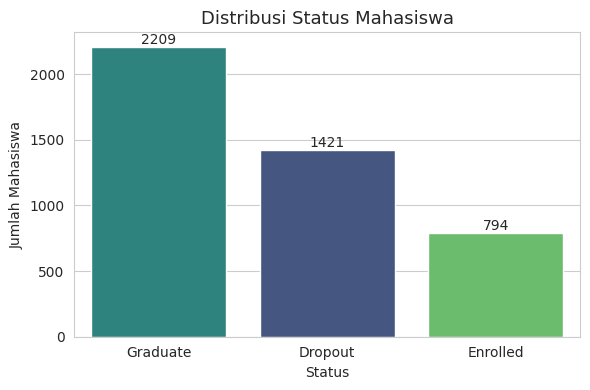

,proportion
Status,
Graduate,49.9
Dropout,32.1
Enrolled,17.9


In [9]:
order_status = df['Status'].value_counts().index

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='Status', order=order_status, hue='Status', palette='viridis', legend=False)
plt.title('Distribusi Status Mahasiswa', fontsize=13)
plt.xlabel('Status')
plt.ylabel('Jumlah Mahasiswa')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

(df['Status'].value_counts(normalize=True) * 100).round(1)


Distribusi status mahasiswa menunjukkan proporsi yang tidak seimbang, dengan mahasiswa berstatus Graduate sebagai kelompok terbesar (sekitar 49,9%), diikuti oleh Dropout (sekitar 32,1%), dan Enrolled sebagai kelompok terkecil (sekitar 17,9%). Ketimpangan proporsi kelas ini menjadi salah satu pertimbangan penting pada tahap pemodelan dan evaluasi, khususnya karena kelas Dropout dan Enrolled memiliki jumlah data yang jauh lebih sedikit dibandingkan Graduate.

#### Hubungan Performa Akademik dengan Status Mahasiswa

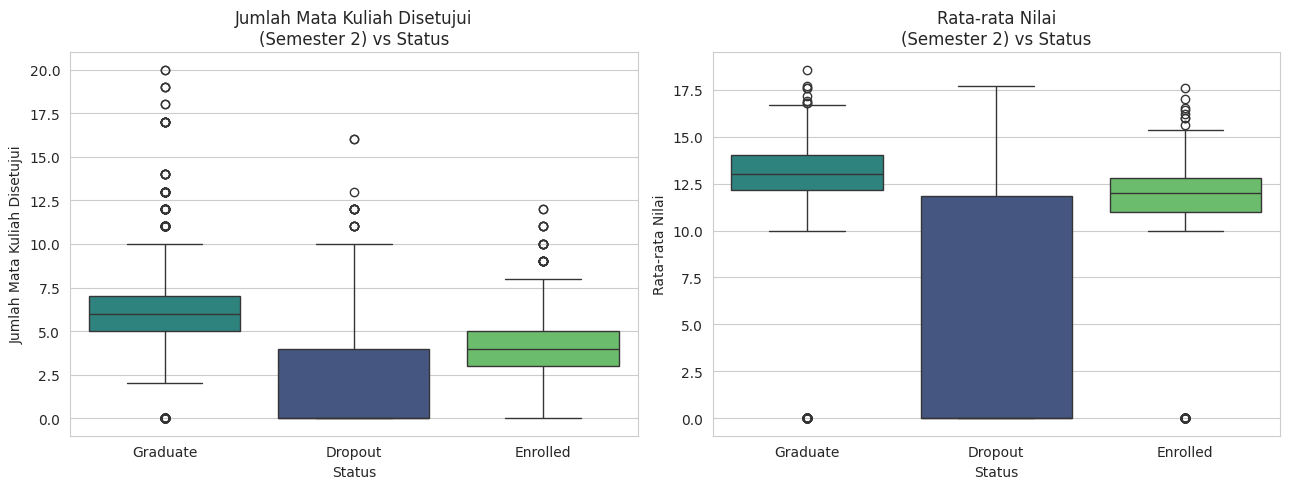

,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade
Status,,
Dropout,0.0,0.0
Enrolled,4.0,12.0
Graduate,6.0,13.0


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x='Status', y='Curricular_units_2nd_sem_approved', order=order_status,
            hue='Status', palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('Jumlah Mata Kuliah Disetujui\n(Semester 2) vs Status')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Jumlah Mata Kuliah Disetujui')

sns.boxplot(data=df, x='Status', y='Curricular_units_2nd_sem_grade', order=order_status,
            hue='Status', palette='viridis', legend=False, ax=axes[1])
axes[1].set_title('Rata-rata Nilai\n(Semester 2) vs Status')
axes[1].set_xlabel('Status')
axes[1].set_ylabel('Rata-rata Nilai')

plt.tight_layout()
plt.show()

df.groupby('Status')[['Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade']].median()


Terlihat perbedaan yang cukup jelas pada performa akademik semester kedua antar kelompok status. Mahasiswa dengan status Dropout memiliki median jumlah mata kuliah yang disetujui sebesar 0, jauh lebih rendah dibandingkan Enrolled (median 4) dan Graduate (median 6). Pola serupa juga terlihat pada rata-rata nilai semester kedua, di mana mahasiswa Dropout memiliki median nilai 0, sedangkan Enrolled dan Graduate memiliki median nilai masing-masing sekitar 12 dan 13. Hal ini mengindikasikan bahwa performa akademik pada semester berjalan merupakan salah satu faktor pembeda utama antara mahasiswa yang dropout dengan mahasiswa yang tetap terdaftar atau lulus.

#### Hubungan Faktor Non-Akademik dengan Status Mahasiswa

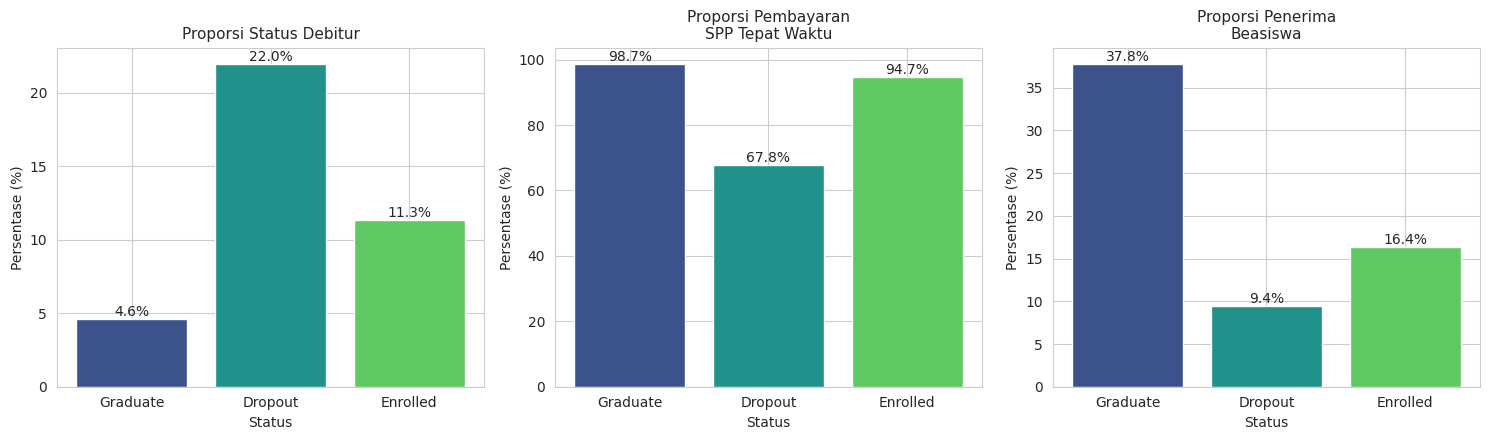

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, kolom, judul in zip(
    axes,
    ['Debtor', 'Tuition_fees_up_to_date', 'Scholarship_holder'],
    ['Proporsi Status Debitur', 'Proporsi Pembayaran\nSPP Tepat Waktu', 'Proporsi Penerima\nBeasiswa']
):
    proporsi = (df.groupby('Status')[kolom].mean() * 100).reindex(order_status)
    ax.bar(proporsi.index, proporsi.values, color=sns.color_palette('viridis', 3))
    ax.set_title(judul, fontsize=11)
    ax.set_xlabel('Status')
    ax.set_ylabel('Persentase (%)')
    for i, v in enumerate(proporsi.values):
        ax.annotate(f'{v:.1f}%', (i, v), ha='center', va='bottom')

plt.tight_layout()
plt.show()


Faktor non-akademik juga menunjukkan pola yang relevan dengan status mahasiswa. Mahasiswa dengan status Dropout memiliki proporsi status debitur tertinggi (sekitar 22,0%) dibandingkan Enrolled (11,3%) dan Graduate (4,6%). Selain itu, hanya sekitar 67,8% mahasiswa Dropout yang tercatat membayar SPP tepat waktu, jauh lebih rendah dibandingkan Enrolled (94,7%) dan Graduate (98,7%). Proporsi penerima beasiswa pada kelompok Dropout juga paling rendah (9,4%) dibandingkan Enrolled (16,4%) dan Graduate (37,8%). Temuan ini mengindikasikan bahwa kondisi finansial mahasiswa, yang tercermin dari status debitur, ketepatan pembayaran SPP, dan status beasiswa, berkaitan dengan kecenderungan mahasiswa untuk dropout.

#### Hubungan Usia Saat Pendaftaran dengan Status Mahasiswa

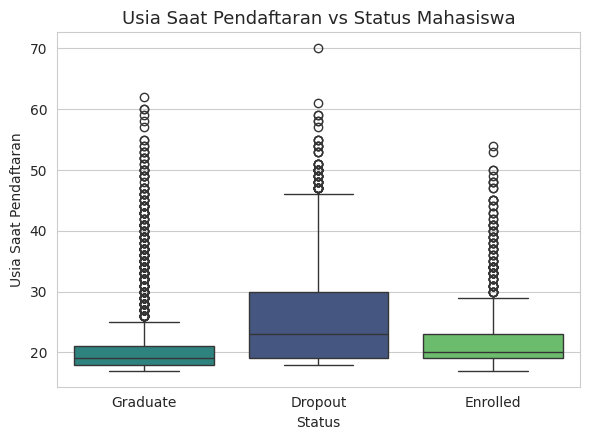

,Age_at_enrollment
Status,
Dropout,23.0
Enrolled,20.0
Graduate,19.0


In [12]:
plt.figure(figsize=(6, 4.5))
sns.boxplot(data=df, x='Status', y='Age_at_enrollment', order=order_status,
            hue='Status', palette='viridis', legend=False)
plt.title('Usia Saat Pendaftaran vs Status Mahasiswa', fontsize=13)
plt.xlabel('Status')
plt.ylabel('Usia Saat Pendaftaran')
plt.tight_layout()
plt.show()

df.groupby('Status')['Age_at_enrollment'].median()


Median usia mahasiswa saat pendaftaran pada kelompok Dropout (23 tahun) sedikit lebih tinggi dibandingkan Enrolled (20 tahun) dan Graduate (19 tahun). Pola ini mengindikasikan bahwa mahasiswa yang mendaftar pada usia yang relatif lebih tua memiliki kecenderungan sedikit lebih besar untuk mengalami dropout, meskipun perbedaannya tidak sebesar faktor akademik dan finansial yang telah dibahas sebelumnya.

#### Korelasi Antar Fitur Numerik

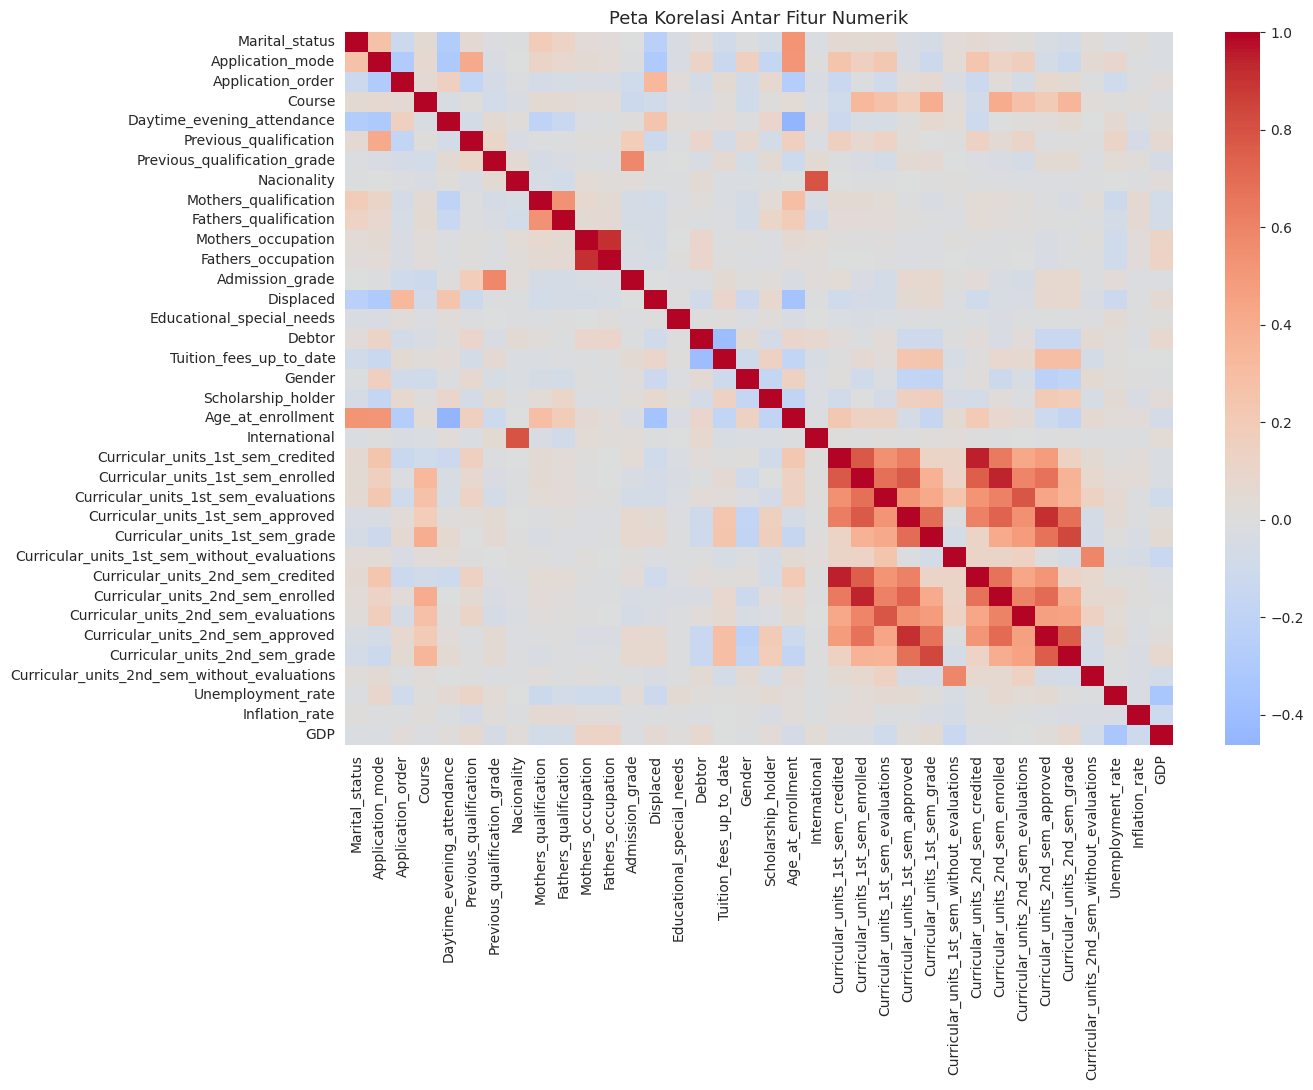

In [13]:
numeric_df = df.select_dtypes(include='number')
plt.figure(figsize=(14, 11))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Peta Korelasi Antar Fitur Numerik', fontsize=13)
plt.tight_layout()
plt.show()


Peta korelasi menunjukkan bahwa fitur-fitur yang berkaitan dengan performa akademik pada semester pertama dan kedua (jumlah mata kuliah yang disetujui, dievaluasi, dan nilai rata-rata) memiliki korelasi yang kuat satu sama lain, sebagaimana wajar terjadi karena kedua semester tersebut berasal dari periode studi yang berdekatan. Hal ini menjadi salah satu pertimbangan pada tahap pemodelan, karena fitur-fitur dengan korelasi tinggi berpotensi memberikan informasi yang saling melengkapi mengenai performa akademik mahasiswa dari waktu ke waktu.

## Data Preparation / Preprocessing

### Pembersihan Data

Berdasarkan pemeriksaan pada tahap Data Understanding, dataset tidak memiliki missing value, data duplikat, maupun indikasi nilai yang tidak valid pada kolom numerik utama. Oleh karena itu, tidak diperlukan penghapusan baris maupun kolom pada tahap pembersihan data ini. Seluruh kolom dipertahankan karena setiap kolom merepresentasikan informasi demografis, sosial-ekonomi, atau akademik yang berpotensi relevan dengan permasalahan dropout mahasiswa.

### Encoding Variabel Target

Variabel target `Status` berupa data kategorikal dengan tiga kelas (Dropout, Enrolled, Graduate). Variabel ini diubah menjadi bentuk numerik menggunakan `LabelEncoder` agar dapat digunakan oleh algoritma machine learning.

In [14]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['Status'])

mapping_status = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
mapping_status


{'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}

### Pemilihan Fitur dan Feature Engineering

Seluruh kolom pada dataset, kecuali kolom `Status`, digunakan sebagai fitur karena telah tersedia dalam bentuk numerik hasil pengkodean dari pihak penyedia dataset (misalnya kode program studi, kode kualifikasi orang tua, dan kode moda pendaftaran). Penambahan fitur turunan (feature engineering) tidak dilakukan pada tahap ini, karena variabel akademik yang tersedia (jumlah mata kuliah yang diambil, dievaluasi, disetujui, beserta nilai rata-rata pada tiap semester) sudah cukup granular untuk merepresentasikan performa akademik mahasiswa. Penambahan fitur agregat tambahan berisiko menimbulkan duplikasi informasi tanpa manfaat yang jelas terhadap performa model, sehingga keputusan ini diambil untuk menjaga kesederhanaan dan interpretabilitas model.

In [15]:
X = df.drop(columns=['Status'])
print("Jumlah fitur yang digunakan:", X.shape[1])


Jumlah fitur yang digunakan: 36


### Train-Test Split

Dataset dibagi menjadi data latih (train) dan data uji (test) dengan proporsi 80:20. Pembagian dilakukan secara stratified berdasarkan variabel target agar proporsi ketiga kelas status pada data latih dan data uji tetap konsisten dengan proporsi pada dataset asli. Nilai `random_state` ditetapkan agar hasil pembagian data dapat direproduksi.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Ukuran data latih:", X_train.shape)
print("Ukuran data uji:", X_test.shape)


Ukuran data latih: (3539, 36)
Ukuran data uji: (885, 36)


### Scaling Fitur

Fitur numerik memiliki rentang nilai yang bervariasi (misalnya usia berkisar puluhan, sedangkan kode program studi berkisar ribuan), sehingga diperlukan penyeragaman skala agar algoritma yang sensitif terhadap skala fitur, seperti Logistic Regression, dapat bekerja secara optimal. Proses scaling dilakukan menggunakan `StandardScaler` yang disatukan ke dalam `Pipeline` bersama masing-masing model, sehingga proses fit scaler hanya dilakukan pada data latih dan tidak melibatkan informasi dari data uji. Pendekatan ini digunakan untuk menghindari kebocoran data (data leakage) dari data uji ke proses pelatihan model.

## Modeling

Permasalahan yang dihadapi merupakan multiclass classification, sehingga tidak ada satu algoritma yang langsung diasumsikan sebagai model terbaik. Tiga algoritma dibandingkan pada tahap ini, yaitu:

- **Logistic Regression**, digunakan sebagai model baseline karena sederhana dan mudah diinterpretasikan.
- **Random Forest**, sebagai model ensemble berbasis bagging yang mampu menangkap hubungan non-linear antar fitur.
- **Gradient Boosting**, sebagai model ensemble berbasis boosting yang membangun model secara bertahap untuk memperbaiki kesalahan model sebelumnya.

Setiap model dibungkus dalam sebuah `Pipeline` yang menyatukan proses scaling dan proses klasifikasi, kemudian dilatih menggunakan data latih yang sama.

In [17]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(random_state=RANDOM_STATE))
    ]),
}

trained_models = {}
predictions = {}

for nama_model, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    trained_models[nama_model] = pipeline
    predictions[nama_model] = y_pred
    print(f"Model {nama_model} selesai dilatih.")


Model Logistic Regression selesai dilatih.
Model Random Forest selesai dilatih.
Model Gradient Boosting selesai dilatih.


## Evaluation

### Perbandingan Model

Setiap model dievaluasi menggunakan metrik accuracy, precision, recall, dan F1-score. Karena permasalahan bersifat multiclass, precision, recall, dan F1-score dihitung menggunakan rata-rata macro agar ketiga kelas (Dropout, Enrolled, Graduate) memiliki bobot yang setara dalam perhitungan, tidak hanya didominasi oleh kelas Graduate yang jumlah datanya paling banyak.

In [18]:
hasil_evaluasi = []

for nama_model in models:
    y_pred = predictions[nama_model]
    akurasi = accuracy_score(y_test, y_pred)
    presisi = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    hasil_evaluasi.append([nama_model, akurasi, presisi, recall, f1])

tabel_perbandingan = pd.DataFrame(
    hasil_evaluasi, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
).sort_values('F1-Score', ascending=False).reset_index(drop=True)

tabel_perbandingan


,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.771751,0.724697,0.681379,0.692373
1,Gradient Boosting,0.759322,0.707266,0.681305,0.690177
2,Logistic Regression,0.768362,0.707005,0.675426,0.682601


In [19]:
for nama_model in models:
    print(f"Classification Report - {nama_model}")
    print(classification_report(y_test, predictions[nama_model], target_names=label_encoder.classes_))
    print('-' * 60)


Classification Report - Logistic Regression
              precision    recall  f1-score   support

     Dropout       0.79      0.77      0.78       284
    Enrolled       0.52      0.33      0.41       159
    Graduate       0.80      0.93      0.86       442

    accuracy                           0.77       885
   macro avg       0.71      0.68      0.68       885
weighted avg       0.75      0.77      0.75       885

------------------------------------------------------------
Classification Report - Random Forest
              precision    recall  f1-score   support

     Dropout       0.81      0.75      0.78       284
    Enrolled       0.58      0.36      0.44       159
    Graduate       0.79      0.93      0.86       442

    accuracy                           0.77       885
   macro avg       0.72      0.68      0.69       885
weighted avg       0.76      0.77      0.76       885

------------------------------------------------------------
Classification Report - Gradient B

### Pemilihan Model Terbaik

Pemilihan model terbaik tidak hanya didasarkan pada accuracy, tetapi juga mempertimbangkan tujuan bisnis utama, yaitu kemampuan model dalam mendeteksi mahasiswa berstatus Dropout. Berdasarkan tabel perbandingan dan classification report di atas, ketiga model menghasilkan performa yang relatif berdekatan pada metrik accuracy dan F1-score secara keseluruhan, dengan Random Forest secara konsisten memberikan accuracy dan rata-rata F1-score (macro) tertinggi di antara ketiga model.

Pada kelas Dropout secara khusus, Random Forest dan Logistic Regression menghasilkan F1-score yang setara, sementara Random Forest unggul pada precision kelas Dropout dan pada penanganan kelas Enrolled yang jumlah datanya paling sedikit. Berdasarkan pertimbangan tersebut, **Random Forest** dipilih sebagai model final karena memberikan keseimbangan terbaik antara performa keseluruhan dan kemampuan mendeteksi kelas Dropout yang menjadi fokus utama permasalahan bisnis.

In [20]:
nama_model_terbaik = 'Random Forest'
model_terbaik = trained_models[nama_model_terbaik]
y_pred_terbaik = predictions[nama_model_terbaik]

print(f"Model terbaik yang dipilih: {nama_model_terbaik}")


Model terbaik yang dipilih: Random Forest


### Confusion Matrix dan Classification Report Model Terbaik

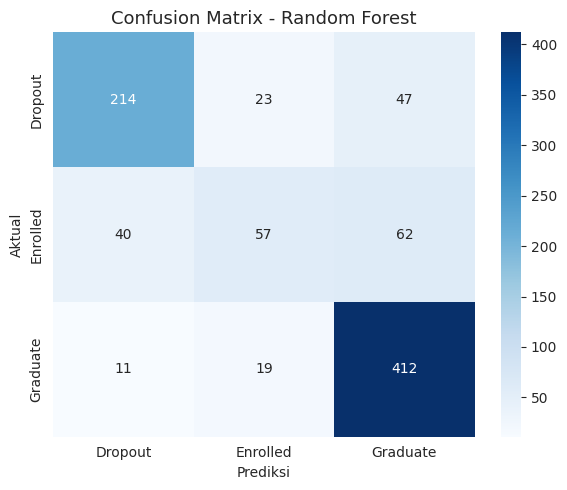

              precision    recall  f1-score   support

     Dropout       0.81      0.75      0.78       284
    Enrolled       0.58      0.36      0.44       159
    Graduate       0.79      0.93      0.86       442

    accuracy                           0.77       885
   macro avg       0.72      0.68      0.69       885
weighted avg       0.76      0.77      0.76       885



In [21]:
cm = confusion_matrix(y_test, y_pred_terbaik)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix - {nama_model_terbaik}', fontsize=13)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_terbaik, target_names=label_encoder.classes_))


Confusion matrix menunjukkan bahwa sebagian besar kesalahan prediksi terjadi antara kelas Dropout dan Enrolled, yang secara akademik memang memiliki karakteristik performa yang berdekatan pada awal periode studi. Meskipun demikian, model tetap mampu mengenali sebagian besar mahasiswa Dropout dan Graduate dengan cukup baik, sehingga model ini dinilai layak untuk dijadikan dasar sistem deteksi dini pada tahap deployment selanjutnya.

### Penyimpanan Model

Model terbaik yang telah dilatih, beserta tahap scaling di dalamnya, disimpan dalam satu `Pipeline` menggunakan `joblib`, sehingga proses praproses dan prediksi dapat digunakan kembali secara konsisten pada tahap deployment tanpa perlu melakukan fitting ulang. Label encoder untuk variabel target turut disimpan agar hasil prediksi dalam bentuk numerik dapat dikembalikan ke label kelas aslinya.

In [22]:
joblib.dump(model_terbaik, 'model_prediksi_dropout.joblib')
joblib.dump(label_encoder, 'label_encoder_status.joblib')

print("Model dan label encoder berhasil disimpan.")


Model dan label encoder berhasil disimpan.


### Ringkasan Hasil

Berdasarkan seluruh tahapan analisis yang telah dilakukan, dapat disimpulkan bahwa performa akademik pada semester berjalan (jumlah mata kuliah yang disetujui dan nilai rata-rata) serta kondisi finansial mahasiswa (status debitur, ketepatan pembayaran SPP, dan status beasiswa) merupakan faktor-faktor yang paling membedakan mahasiswa dengan status Dropout, Enrolled, dan Graduate. Model Random Forest yang telah dilatih dan disimpan pada tahap ini dapat digunakan sebagai dasar sistem deteksi dini mahasiswa berpotensi dropout pada tahap deployment berikutnya menggunakan aplikasi Streamlit.